___
# **MRI Inpainting Demo**
## Instructor -- Rizwan Ahmad (ahmad.46@osu.edu)
## BME5710 -- Spring 2026

This notebook demonstrates a minimal PyTorch pipeline for MRI inpainting.

**What it covers:**
1. Load training images and normalize to float32 in [0, 1]
2. Split into 225 training and 25 validation images
3. Apply a random i.i.d. Bernoulli mask (75% missing pixels) in the data loader
4. Train a single-layer CNN using MSE loss
5. Evaluate each epoch with PSNR and the competition metric: PSNR + 50×SSIM
6. Run inference on masked test images and save a Kaggle-ready submission.csv

**Network input/output:**
- Input: 2-channel tensor — channel 1 = masked image, channel 2 = binary mask (1=observed, 0=missing)
- Output: 1-channel reconstructed image (float32 in [0, 1])

**Folder structure (relative to this notebook):**
```
project/
  demo_inpainting.ipynb    ← this notebook
  train/                   ← 250 training TIFFs (train_000.tif ... train_249.tif)
  test-masked/             ← 50 masked TIFFs + 50 binary mask TIFFs
  model.pth                ← saved model weights (created by this notebook)
  submission.csv           ← Kaggle submission (created by this notebook)
```

___
### Import libraries

In [1]:
# pip install numpy pandas matplotlib pillow scikit-image pytorch-msssim torch torchvision torchaudio

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image                                        # for reading TIFF files
from skimage.metrics import peak_signal_noise_ratio as skpsnr  # PSNR metric
from skimage.metrics import structural_similarity as skssim    # SSIM metric

from pytorch_msssim import ssim
import torch
import torch.nn as nn                                        # neural network modules
from torch.utils.data import Dataset, DataLoader             # data handling utilities

___
### Calling a custom code to change the default font for figures to `Computer Modern`. (Optional)

In [3]:
from fontsetting import font_cmu                             # custom font helper
plt = font_cmu(plt)                                          # set Computer Modern font

___
### Predefine parameters

In [ ]:
train_folder        = "train"          # folder with training TIFFs
test_masked_folder  = "test-masked"    # folder with masked test TIFFs
imag_size           = 256              # image dimensions (H = W)
mask_ratio          = 0.75             # fraction of pixels that are missing
m_tr                = 235              # number of training images
m_val               = 15               # number of validation images
m_te                = 50               # number of test images
batch_size          = 4                # mini-batch size
n_epochs            = 150              # number of training epochs
seed                = 0                # random seed for reproducibility

torch.manual_seed(seed)                # seed PyTorch RNG
np.random.seed(seed)                   # seed NumPy RNG

if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")
    
print(f"Using device: {DEVICE}")


Using device: mps


___
### Helper functions

In [5]:
# Helper function to list non-hidden files in a folder (ignoring .DS_Store and other dot-files).
def visible_files(folder):
    """Return non-hidden files in a folder (ignores .DS_Store and other dot-files)."""
    return [f for f in os.listdir(folder) if not f.startswith('.')]  # skip hidden files


# Compute the PSNR and competition metric (PSNR + 50×SSIM) for a batch of predictions and targets.
def compute_metrics(pred, target):
    """
    Compute PSNR and the competition metric (PSNR + 50×SSIM)
    averaged over a batch.
    """
    pred_np   = np.clip(pred.detach().cpu().numpy(), 0, 1)    # (B, 1, H, W), clamp to [0,1]
    target_np = np.clip(target.detach().cpu().numpy(), 0, 1) # (B, 1, H, W), clamp to [0,1]

    psnr_list   = []
    metric_list = []

    for i in range(pred_np.shape[0]):                        # loop over batch
        p = pred_np[i, 0]                                    # predicted image (H, W)
        t = target_np[i, 0]                                  # target image (H, W)

        psnr = skpsnr(t, p, data_range=1.0)                  # peak signal-to-noise ratio
        ssim = skssim(t, p, data_range=1.0)                  # structural similarity

        psnr_list.append(psnr)
        metric_list.append(psnr + 50.0 * ssim)               # competition metric

    return np.mean(psnr_list), np.mean(metric_list)

___
### Load training images

In [6]:
def load_images(folder):
    """
    Load all TIFFs from a folder.
    Returns a list of float32 numpy arrays normalized to [0, 1].
    Handles both uint8 and uint16 source images automatically.
    """
    files = sorted([                                         # collect TIFF filenames
        f for f in visible_files(folder)
        if f.lower().endswith('.tif') or f.lower().endswith('.tiff')
    ])
    assert len(files) > 0, f"No TIFF files found in {folder}"

    images = []
    for fname in files:
        with Image.open(os.path.join(folder, fname)) as im:
            img = np.array(im)
        if img.dtype == np.uint16:                         # 16-bit → divide by 65535
            img = img.astype(np.float32) / 65535.0
        elif img.dtype == np.uint8:                        # 8-bit → divide by 255
            img = img.astype(np.float32) / 255.0
        else:                                                # already float → use as-is
            img = img.astype(np.float32)
        assert img.shape == (imag_size, imag_size), (
            f"Unexpected shape {img.shape} for {fname}; expected ({imag_size}, {imag_size})"
        )
        images.append(img)

    print(f"Loaded {len(images)} images from '{folder}'")
    return images


all_images = load_images(train_folder)                       # load all 250 images
assert len(all_images) == m_tr + m_val, (
    f"Expected {m_tr + m_val} images, found {len(all_images)}"
)

train_images = all_images[:m_tr]                             # first 225 for training
val_images   = all_images[m_tr:]                             # last 25 for validation
print(f"Split: {len(train_images)} train | {len(val_images)} validation")

Loaded 250 images from 'train'
Split: 235 train | 15 validation


___
### Dataset and DataLoader

In [7]:
class InpaintingDataset(Dataset):
    def __init__(self, images, mask_ratio=0.75, fixed_masks=None):
        self.images = images
        self.mask_ratio = mask_ratio
        self.fixed_masks = fixed_masks

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        full_img = self.images[idx].copy().astype(np.float32)

        # Apply augmentation only during training
        if self.fixed_masks is None:
            if np.random.rand() > 0.5:
                full_img = np.flip(full_img, axis=1)
            if np.random.rand() > 0.5:
                full_img = np.flip(full_img, axis=0)
            k = np.random.randint(0, 4)
            full_img = np.rot90(full_img, k=k)

        # Make sure array is contiguous after flip/rot90
        full_img = np.ascontiguousarray(full_img)

        if self.fixed_masks is not None:
            mask = self.fixed_masks[idx].astype(np.float32)
        else:
            mask = (np.random.rand(*full_img.shape) > self.mask_ratio).astype(np.float32)

        mask = np.ascontiguousarray(mask)
        masked_img = np.ascontiguousarray(full_img * mask)

        full_img   = torch.from_numpy(full_img[None])
        masked_img = torch.from_numpy(masked_img[None])
        mask       = torch.from_numpy(mask[None])

        return masked_img, mask, full_img


val_fixed_masks = [
    (np.random.rand(*img.shape) > mask_ratio).astype(np.float32)
    for img in val_images
]

train_dataset = InpaintingDataset(train_images, mask_ratio=mask_ratio)
val_dataset   = InpaintingDataset(val_images, mask_ratio=mask_ratio, fixed_masks=val_fixed_masks)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)   # shuffle for training
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False)  # no shuffle for validation

print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")

Train batches: 15 | Val batches: 1


___
### Built your CNN model (U-Net Attempt)

In [ ]:
class AttentionGate(nn.Module): # Attention gate for skip connections
    def __init__(self, F_g, F_l, F_int):
        """
        F_g: Number of channels in the gating signal (from lower layer)
        F_l: Number of channels in the skip connection (from encoder)
        F_int: Number of intermediate channels (usually F_l // 2)
        """
        super().__init__()
        
        self.W_g = nn.Sequential(
            nn.Conv2d(F_g, F_int, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(F_int)
        )
        
        self.W_x = nn.Sequential(
            nn.Conv2d(F_l, F_int, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(F_int)
        )
        self.psi = nn.Sequential(
            nn.Conv2d(F_int, 1, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(1),
            nn.Sigmoid()
        )
        self.relu = nn.ReLU(inplace=True)

    def forward(self, g, x):
        g1 = self.W_g(g)
        x1 = self.W_x(x)
        psi = self.relu(g1 + x1)
        psi = self.psi(psi)
        return x * psi

class ResBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        
        # Shortcut connection to match dimensions if they change
        self.shortcut = nn.Sequential()
        if in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        residual = self.shortcut(x)
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += residual
        out = self.relu(out)
        return out


class UNet(nn.Module):
    def __init__(self):
        super().__init__()

        # Encoder
        self.enc1 = ResBlock(2, 48)
        self.pool1 = nn.MaxPool2d(2)

        self.enc2 = ResBlock(48, 96)
        self.pool2 = nn.MaxPool2d(2)

        self.enc3 = ResBlock(96, 192)
        self.pool3 = nn.MaxPool2d(2)

        self.enc4 = ResBlock(192, 384)
        self.pool4 = nn.MaxPool2d(2)

        # Bottleneck
        self.bottleneck = nn.Sequential(
            ResBlock(384, 768),
            # This block has a 'receptive field' twice as large
            nn.Conv2d(768, 768, kernel_size=3, padding=2, dilation=2, bias=False),
            nn.BatchNorm2d(768),
            nn.ReLU(inplace=True),
            ResBlock(768, 768)
        )
        # Decoder

        self.up4 = nn.Sequential(nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True), nn.Conv2d(768, 384, kernel_size=3, padding=1))
        self.dec4 = ResBlock(768, 384) 

        self.up3 = nn.Sequential(nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True), nn.Conv2d(384, 192, kernel_size=3, padding=1))
        self.dec3 = ResBlock(384, 192) 

        self.up2 = nn.Sequential(nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True), nn.Conv2d(192, 96, kernel_size=3, padding=1))
        self.dec2 = ResBlock(192, 96) 

        self.up1 = nn.Sequential(nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True), nn.Conv2d(96, 48, kernel_size=3, padding=1))
        self.dec1 = ResBlock(96, 48)

        # Attention gates for skip connections
        self.att4 = AttentionGate(F_g=384, F_l=384, F_int=192)
        self.att3 = AttentionGate(F_g=192, F_l=192, F_int=96)
        self.att2 = AttentionGate(F_g=96,  F_l=96,  F_int=48)
        self.att1 = AttentionGate(F_g=48,  F_l=48,  F_int=24)

        # Final output layer
        self.out_conv = nn.Conv2d(48, 1, kernel_size=1)

    def forward(self, masked_img, mask):
        x = torch.cat([masked_img, mask], dim=1)   # [B, 2, 256, 256]

        # Encoder
        e1 = self.enc1(x)        # [B, 48, , 256]
        p1 = self.pool1(e1)      # [B, 48, 128, 128]

        e2 = self.enc2(p1)       # [B, 96, 128, 128]
        p2 = self.pool2(e2)      # [B, 96, 64, 64]

        e3 = self.enc3(p2)       # [B, 192, 64, 64]
        p3 = self.pool3(e3)      # [B, 192, 32, 32]

        e4 = self.enc4(p3)       # [B, 384, 32, 32]
        p4 = self.pool4(e4)      # [B, 384, 16, 16]

        # Bottleneck
        b = self.bottleneck(p4)  # [B, 768, 16, 16]

        # Decoder

        u4 = self.up4(b)          # [B, 256, 32, 32]
        s4 = self.att4(g=u4, x=e4) 
        u4_cat = torch.cat([u4, s4], dim=1) 
        d4 = self.dec4(u4_cat)

        u3 = self.up3(d4)        # [B, 128, 64, 64]
        s3 = self.att3(g=u3, x=e3)
        u3_cat = torch.cat([u3, s3], dim=1)
        d3 = self.dec3(u3_cat)

        u2 = self.up2(d3)        # [B, 64, 128, 128]
        s2 = self.att2(g=u2, x=e2)
        u2_cat = torch.cat([u2, s2], dim=1)
        d2 = self.dec2(u2_cat)

        u1 = self.up1(d2)        # [B, 32, 256, 256]
        s1 = self.att1(g=u1, x=e1)
        u1_cat = torch.cat([u1, s1], dim=1)
        d1 = self.dec1(u1_cat)

        out = self.out_conv(d1)
        
        return out
    
model     = UNet().to(DEVICE)                      # instantiate and move to device
optimizer = torch.optim.Adam(model.parameters(), lr=2e-4 * (batch_size/4)) # Scale learning rate with batch size (base LR is for batch size 4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model initialized. Trainable parameters: {n_params}")

Model initialized. Trainable parameters: 36335461


___
### Training loop

In [9]:
import torch.nn as nn
l1_loss_fn = nn.L1Loss()

best_val_metric = -float("inf")


print(f"{'Epoch':>5} | {'Train Loss':>12} | {'Train Metric':>14} | {'Val Loss':>10} | {'Val Metric':>12}")
print("-" * 65)

for epoch in range(1, n_epochs + 1):

    # ── Training ─────────────────────────────────────────────────────────────
    model.train()                                            # set model to training mode
    train_loss_sum   = 0.0
    train_metric_sum = 0.0
    train_n          = 0

    for masked_img, mask, full_img in train_loader:          # iterate over mini-batches
        masked_img = masked_img.to(DEVICE)
        mask       = mask.to(DEVICE)
        full_img   = full_img.to(DEVICE)

        optimizer.zero_grad()                             # reset gradients
        pred = model(masked_img, mask)                       # raw model output
        pred = torch.clamp(pred, 0.0, 1.0)
        recon = mask * masked_img + (1 - mask) * pred       # A: preserve known pixels instead of using raw output
        missing = 1 - mask
        known = mask
        
        l1_loss = torch.mean(torch.abs((recon - full_img) * (missing)))
        ssim_loss = 1 - ssim(recon, full_img)
        loss = 0.45 * l1_loss + 0.55 * ssim_loss

        loss.backward()
        optimizer.step()

        batch_size = full_img.shape[0]
        _, batch_metric = compute_metrics(recon, full_img)  # (PSNR + 50×SSIM) metric should use final reconstruction

        train_loss_sum   += loss.item() * batch_size
        train_metric_sum += batch_metric * batch_size
        train_n          += batch_size

    train_loss   = train_loss_sum   / train_n                # average training loss
    train_metric = train_metric_sum / train_n                # average training metric

    # ── Validation ───────────────────────────────────────────────────────────
    model.eval()                                             # set model to eval mode
    val_loss_sum   = 0.0
    val_metric_sum = 0.0
    val_n          = 0

    with torch.no_grad():                                    # disable gradient tracking
        for masked_img, mask, full_img in val_loader:
            masked_img = masked_img.to(DEVICE)
            mask       = mask.to(DEVICE)
            full_img   = full_img.to(DEVICE)

            pred = model(masked_img, mask)                   # forward pass
            pred = torch.clamp(pred, 0.0, 1.0)
            recon = mask * masked_img + (1 - mask) * pred       # A: preserve known pixels instead of using raw output
            missing = 1 - mask
            known = mask

            l1_loss = torch.mean(torch.abs((recon - full_img) * (missing)))
            ssim_loss = 1 - ssim(recon, full_img)
            loss = 0.45 * l1_loss + 0.55 * ssim_loss

            
            batch_size = full_img.shape[0]
            _, batch_metric = compute_metrics(recon, full_img)
            val_loss_sum   += loss.item() * batch_size
            val_metric_sum += batch_metric * batch_size
            val_n          += batch_size

    val_loss   = val_loss_sum   / val_n                      # average validation loss
    val_metric = val_metric_sum / val_n                      # average validation metric

    print(f"{epoch:>5} | {train_loss:>12.6f} | {train_metric:>14.4f} | {val_loss:>10.6f} | {val_metric:>12.4f}")

    if val_metric > best_val_metric: # Save best Model
        best_val_metric = val_metric
        torch.save(model.state_dict(), "best_model.pth")
        print("  Saved new best model.")
    
    scheduler.step(val_metric)
        
# print out the min/max values for the recovered images

Epoch |   Train Loss |   Train Metric |   Val Loss |   Val Metric
-----------------------------------------------------------------
    1 |     0.043086 |        35.4078 |   0.059505 |      26.9350
  Saved new best model.
    2 |     0.015146 |        57.2507 |   0.031937 |      43.0595
  Saved new best model.
    3 |     0.014716 |        58.8949 |   0.015441 |      58.6531
  Saved new best model.
    4 |     0.013180 |        61.6837 |   0.012290 |      61.7504
  Saved new best model.
    5 |     0.012090 |        63.5147 |   0.013352 |      61.2712
    6 |     0.011652 |        64.1778 |   0.011192 |      63.4857
  Saved new best model.
    7 |     0.010485 |        65.8798 |   0.010500 |      67.4619
  Saved new best model.
    8 |     0.010103 |        66.7900 |   0.011801 |      63.0800
    9 |     0.009777 |        67.4608 |   0.010345 |      68.9265
  Saved new best model.
   10 |     0.009539 |        68.2617 |   0.009605 |      68.9922
  Saved new best model.
   11 |     0.00

___
### Visualize results

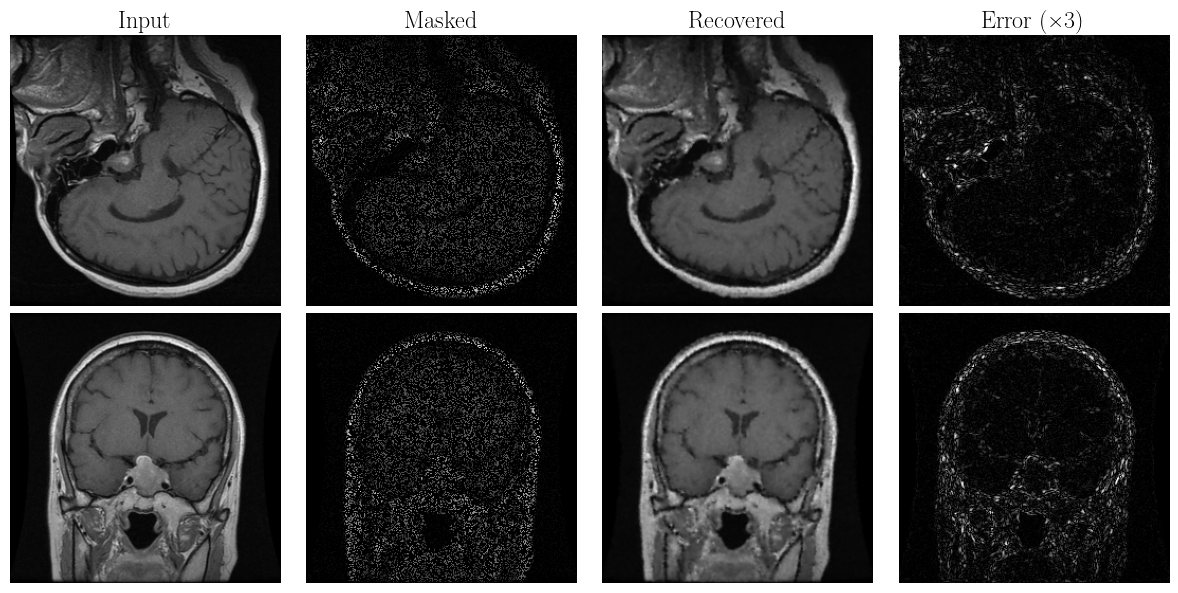

In [10]:
import random

model.load_state_dict(torch.load("best_model.pth", map_location=DEVICE))
model.eval()

fig, axes = plt.subplots(2, 4, figsize=(12, 6))             # 2 rows × 4 columns

for row, dataset in enumerate([train_dataset, val_dataset]): # row 0 = train, row 1 = val
    idx = random.randint(0, len(dataset) - 1)                # pick a random sample
    masked_img, mask, full_img = dataset[idx]                # each (1, H, W)

    with torch.no_grad():
        masked_batch = masked_img[None].to(DEVICE)
        mask_batch   = mask[None].to(DEVICE)
        pred = model(masked_batch, mask_batch)
        pred = torch.clamp(pred, 0.0, 1.0)
        recovered = mask_batch * masked_batch + (1 - mask_batch) * pred
        recovered = recovered.cpu()

    orig   = full_img[0].numpy()                             # ground truth
    masked = masked_img[0].numpy()                           # masked input
    rec    = recovered[0, 0].numpy()                         # model output
    err    = np.abs(orig - rec) * 3                          # amplified error map

    for ax, img, title in zip(axes[row], [orig, masked, rec, err],
                               ["Input", "Masked", "Recovered", "Error (×3)"]):
        ax.imshow(img, cmap="gray", vmin=0, vmax=1)
        if row == 0:
            ax.set_title(title)
        ax.axis("off")

axes[0, 0].set_ylabel("Train", fontsize=12)
axes[1, 0].set_ylabel("Val", fontsize=12)
plt.tight_layout()
plt.show()

___
### Inference on test images

Load each masked test image and its binary mask from `test-masked/`, run the trained
network, and stack the reconstructions into a single `(50, 256, 256)` float32 array
saved as `submission.csv`.

**Note:** The `_mask.tif` files were saved with pixel values 0/255. We divide by 255
when loading to recover the 0/1 float mask expected by the network.

Found 50 masked test images and 50 mask files.


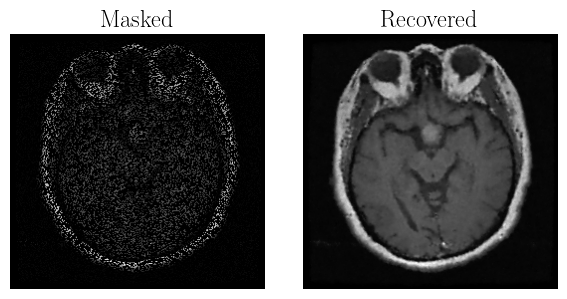

In [11]:
def load_test_sample(masked_path, mask_path):
    """
    Load a masked test image and its binary mask.
    Returns tensors ready for model input: (1, 1, H, W).
    """
    with Image.open(masked_path) as im:
        masked_img = np.array(im)
    if masked_img.dtype == np.uint16:                        # 16-bit → divide by 65535
        masked_img = masked_img.astype(np.float32) / 65535.0
    elif masked_img.dtype == np.uint8:                       # 8-bit → divide by 255
        masked_img = masked_img.astype(np.float32) / 255.0
    else:                                                    # already float → use as-is
        masked_img = masked_img.astype(np.float32)

    with Image.open(mask_path) as im:
        mask = np.array(im).astype(np.float32) / 255.0       # 0/255 uint8 → 0/1 float

    masked_img = torch.from_numpy(masked_img[None, None])    # (H,W) → (1,1,H,W)
    mask       = torch.from_numpy(mask[None, None])          # (H,W) → (1,1,H,W)

    return masked_img, mask


# Collect and sort masked images and their corresponding masks
all_test_files = sorted([
    f for f in visible_files(test_masked_folder)
    if f.lower().endswith('.tif') or f.lower().endswith('.tiff')
])

masked_files = [f for f in all_test_files if f.endswith('_masked.tif')]  # input images
mask_files   = [f for f in all_test_files if f.endswith('_mask.tif')]    # binary masks

assert len(masked_files) == m_te, f"Expected {m_te} masked images, found {len(masked_files)}"
assert len(mask_files)   == m_te, f"Expected {m_te} mask files, found {len(mask_files)}"

print(f"Found {len(masked_files)} masked test images and {len(mask_files)} mask files.")

# Run inference
model.load_state_dict(torch.load("best_model.pth", map_location=DEVICE))
model.eval()
reconstructions = []

with torch.no_grad():                                        # no gradients for inference
    for masked_fname, mask_fname in zip(masked_files, mask_files):
        masked_img, mask = load_test_sample(
            os.path.join(test_masked_folder, masked_fname),
            os.path.join(test_masked_folder, mask_fname)
        )
        masked_img = masked_img.to(DEVICE)
        mask       = mask.to(DEVICE)

        pred = model(masked_img, mask)                       # forward pass → (1,1,H,W)
        pred = torch.clamp(pred, 0.0, 1.0)
        recon = mask * masked_img + (1 - mask) * pred       # A: preserve known pixels instead of using raw output
        recon = recon.squeeze().cpu().numpy()                  # → (H, W)
        recon = np.clip(recon, 0.0, 1.0)                       # clamp to [0, 1]
        reconstructions.append(recon)

# Plot a random test sample
idx = random.randint(0, len(reconstructions) - 1)
test_masked = Image.open(os.path.join(test_masked_folder, masked_files[idx]))
fig, axes = plt.subplots(1, 2, figsize=(6, 3))
axes[0].imshow(np.array(test_masked).astype(np.float32), cmap="gray")
axes[0].set_title("Masked"); axes[0].axis("off")
axes[1].imshow(reconstructions[idx], cmap="gray", vmin=0, vmax=1)
axes[1].set_title("Recovered"); axes[1].axis("off")
plt.tight_layout()
plt.show()

___
### Prepare `submission.csv` to upload on Kaggle

In [12]:
# Flatten each (256, 256) reconstruction into a row of 65536 pixels
pixel_cols = [f"pixel_{j}" for j in range(imag_size * imag_size)]
rows = [rec.ravel() for rec in reconstructions]

submission_df = pd.DataFrame(rows, columns=pixel_cols, dtype=np.float32)
submission_df.insert(0, "id", [f"img_{i:03d}" for i in range(m_te)])

submission_df.to_csv("submission.csv", index=False)

print(f"Submission saved to submission.csv")
print(f"  Shape : {submission_df.shape}")
print(f"  Range : [{submission_df[pixel_cols].min().min():.4f}, {submission_df[pixel_cols].max().max():.4f}]")

Submission saved to submission.csv
  Shape : (50, 65537)
  Range : [0.0000, 1.0000]
